Let's load the necessary libraries

In [1]:
from openai import OpenAI # Used for accessing LLMs using the OpenAI API
import pandas as pd # Used for data manipulation
import matplotlib.pyplot as plt # Used for plotting
from huggingface_hub import login # Used to log in to Hugging Face and access datasets
from pydantic import BaseModel, ValidationError # Used for validating the output from the LLM
import json # Used for parsing JSON output from the LLM

We will use Ollama, which allows us to run large language models locally on our machine without needing to access a cloud-based API. This is useful for testing and development purposes, as it allows us to work with LLMs without incurring costs or needing an internet connection. 

First, we need to download a pre-trained model that we can run locally using Ollama. We can do this using the ollama pull command in the terminal. For example, we can download the Gemma 3 270m model, which is a smaller version of the Gemma 3 family that can run on a local machine without requiring a GPU.

In [2]:
#!ollama pull gemma3:270m

In [3]:
model = "gemma3:270m" # The name of the model we downloaded and want to use with Ollama

To use the Ollama API, we then need to start the Ollama server on our machine. We can do this using the following command in the terminal:

```bash
ollama serve
```

This will start the Ollama server and make the LLM API available at http://localhost:11434/v1. For convenience, we can also start the Ollama server from within our Python code using the subprocess module, which allows us to run shell commands from Python.

In [4]:
import subprocess
process = subprocess.Popen(["ollama", "serve"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

Now that we have the Ollama server running, we can create a client to access the LLM API. The OpenAI library provides a convenient interface for accessing the LLM API, and we can use it to create a client that connects to our local Ollama server.

In [5]:
client = OpenAI(
    base_url = "http://localhost:11434/v1", # Ollama endpoint for accessing the local LLM API
    api_key = "" # No API key is needed for the local Ollama API, but we need to provide an empty string to avoid authentication errors
)

Then, we can use the client to send a request to the LLM API and get a response. For example, we can send a simple chat completion request to the API and print the response.

In [6]:
response = client.chat.completions.create(
    model = model,
    messages = [
        {"role": "system", "content": "You are a helpful assistant."},
        {"role": "user", "content": "What is inflation?"},
    ]
)

print(f"{response.choices[0].message.role}: {response.choices[0].message.content}")

assistant: Inflation is the increase in the general price level of goods and services in an economy over a period of time. It's a serious issue that affects businesses, consumers, and the overall economic environment.



In this example, we are sending a chat completion request to the LLM API using the "gemma3:270m" model, which is the smallest version of Gemma 3, an open-source model by Google, that can run on a local machine without requiring a GPU. The request includes a system message that sets the context for the conversation and a user message that asks the question "What is inflation?". The response from the API includes a message from the assistant role that provides an answer to the user's question.

Using APIs can be very costly if we are making a large number of requests. We can check how many tokens we have used in our request and response to get an idea of the cost of using the API. The OpenAI library provides a convenient way to access the token usage information from the response.

In [7]:
print(f"Tokens used: {response.usage.total_tokens}")
print(f"Input tokens: {response.usage.prompt_tokens}")
print(f"Output tokens: {response.usage.completion_tokens}")

Tokens used: 63
Input tokens: 21
Output tokens: 42


:::{.callout-note}
#### API Pricing
Since we are using a local model with Ollama, we do not incur any costs for using the API. However, when using cloud-based APIs, costs are typically charged per token (both input and output). For example, at the time of writing (early 2026), OpenAI charges \$1.75 per million input tokens and \$14.00 per million output tokens for GPT 5.2. Pricing changes frequently, so always check the provider's current pricing page before running large batch jobs.
:::


### Exploring the Probabilistic Nature of LLMs

LLMs are probabilistic models since they generate output based on a probability distribution over possible next tokens. This is why the same input can lead to different outputs each time we send a request to the API. The model samples from this probability distribution to generate its response, which can lead to variability in the output even for the same input. This is an important aspect of LLMs to keep in mind, especially when using them for tasks that require consistency or when evaluating their performance, as the variability in the output can affect the results.

Consider the following function that sends a request to the LLM API to answer a question about the most beautiful city in Europe. If we call this function multiple times, we may get different answers each time due to the probabilistic nature of the model.

In [8]:
def city_question():

    response = client.chat.completions.create(
        model = model,
        messages = [
            {"role": "system", "content": "You are a helpful assistant."},
            {"role": "user", "content": "What is the most beautiful city in Europe? Answer with one word."},
        ]
    )

    return response.choices[0].message.content

Now we can call this function multiple times to see the variability in the output.

In [9]:
for ii in range(10):
    print(f"Run {ii + 1}: {city_question()}")

Run 1: Paris

Run 2: Rome



Run 3: Rome

Run 4: Paris



Run 5: Paris

Run 6: Paris



Run 7: Paris

Run 8: Rome



Run 9: Rome

Run 10: Versailles



You can see that it often answers with "Paris", but sometimes with "Rome", "Barcelona", or other cities. This illustrates an important property of LLMs: because they sample from a probability distribution over tokens, there is no guarantee that the same input will produce the same output. This variability is particularly relevant for tasks that require reliability and consistency, such as automated data extraction or classification pipelines. Furthermore, we also have no guarantee that the output will be factually correct, as the model may generate plausible-sounding but incorrect answers (known as "hallucinations").


#### Temperature and Sampling {.unnumbered}

When we send a request to the LLM API, we can also specify some parameters that control the behavior of the model. For example, we can specify the temperature parameter, which adjusts the probability distribution of the model's output. A higher temperature will result in more random output, while a lower temperature will result in more deterministic output.

In [10]:
def ask_question(question, temperature=0.7, top_p=0.9):

    response = client.chat.completions.create(
        model = model,
        messages = [
            {"role": "system", "content": "You are a helpful assistant."},
            {"role": "user", "content": question},
        ],
        temperature=temperature, # Higher temperature for more random output
        top_p=top_p, # Nucleus sampling parameter to control the diversity of the output
    )

    return response.choices[0].message.content

Now we can ask the same question with different temperature settings to see how it affects the output of the model.

In [11]:
question = "Who is the best Olympic athlete of all time? Only provide the name without any explanations or additional text."

print("Temperature = 0.0 (Least random output):")

for ii in range(3):
    print(f"Run {ii + 1}: {ask_question(question, temperature=0.0)}")

print("\nTemperature = 0.7 (More random output):")

for ii in range(3):
    print(f"Run {ii + 1}: {ask_question(question, temperature=0.7)}")

print("\nTemperature = 2.0 (Even more random output):")

for ii in range(3):
    print(f"Run {ii + 1}: {ask_question(question, temperature=2.0)}")

Temperature = 0.0 (Least random output):


Run 1: Simone Biles

Run 2: Simone Biles



Run 3: Simone Biles


Temperature = 0.7 (More random output):
Run 1: Michael Phelps



Run 2: Simone Biles



Run 3: Simone Biles


Temperature = 2.0 (Even more random output):
Run 1: Michael Jordan



Run 2: He passed the gold medal ceremony at the 1988 Games.
Run 3: Adam Phelps



Similarly, we can also specify the top_p parameter, which controls the nucleus sampling of the model's output. For example, we can set top_p to 0.9, which means that the model will only consider the top 90% of the probability mass when generating the output. Thus, a lower top_p will result in more focused output, while a higher top_p will result in more diverse output.

In [12]:
print("Top-p = 0.1 (More focused output):")
for ii in range(3):
    print(f"Run {ii + 1}: {ask_question(question, top_p=0.1)}")

print("\nTop-p = 0.9 (More diverse output):")
for ii in range(3):
    print(f"Run {ii + 1}: {ask_question(question, top_p=0.9)}")

Top-p = 0.1 (More focused output):


Run 1: Simone Biles



Run 2: Simone Biles



Run 3: Simone Biles


Top-p = 0.9 (More diverse output):
Run 1: Michael Phelps



Run 2: Simone Biles



Run 3: Simone Biles



Note that if neither temperature nor top_p is specified, the model will use the default values. These default values may differ between models and providers.


### Zero-Shot and Few-Shot Classification

For this section, we will again use a pre-labeled dataset for sentence-level sentiment analysis of ECB speeches [@Pfeifer2023], which is available on Hugging Face ([Central Bank Communication Dataset](https://huggingface.co/datasets/Moritz-Pfeifer/CentralBankCommunication)). The dataset contains sentences from ECB speeches that have been labeled as positive or negative in terms of sentiment.

Let's load the dataset into a pandas DataFrame

In [13]:
df = pd.read_csv("hf://datasets/Moritz-Pfeifer/CentralBankCommunication/Sentiment/ECB_prelabelled_sent.csv")

Then, we can define a function that takes a sentence as input and uses the LLM API to classify the sentiment of the sentence as positive or negative. We will use a zero-shot classification approach, where we provide the model with a prompt that describes the task and the possible labels, but we do not provide any examples of labeled sentences.

In [14]:
def classify_sentiment(sentence):

    prompt = f"""Read the following sentence from a central bank speech and decide whether it expresses an optimistic or pessimistic view of the economy.

    Sentence: "{sentence}"

    Answer with exactly one word: 'positive' if optimistic, 'negative' if pessimistic."""

    response = client.chat.completions.create(
        model = model,
        messages = [
            {"role": "system", "content": "You are a helpful assistant that classifies the sentiment of sentences."},
            {"role": "user", "content": prompt},
        ]
    )

    return response.choices[0].message.content.strip().lower()

Now we can apply this function to the sentences in our dataset to get the predicted sentiment labels from the LLM API.

In [15]:
pd.DataFrame({
    "sentence": df["text"].iloc[949:959],
    "true_sentiment": df["sentiment"].iloc[949:959],
    "predicted_sentiment": df["text"].iloc[949:959].apply(classify_sentiment)
})

,sentence,true_sentiment,predicted_sentiment
949,47 in any case economic interdependence will i...,1,negative
950,over the last 15 years the financial sector ha...,1,negative
951,first the integration of our economies and wit...,1,negative
952,we expect that further deregulation as well as...,1,negative
953,output growth has been gathering pace througho...,1,negative
954,in this regard the crisis has uncovered four s...,0,negative
955,the second challenge concerns another aspect o...,0,negative
956,6 such differences in institutional quality ar...,0,negative
957,third a number of other factors show up in an ...,0,negative
958,in 2007 the us current account deficit amounte...,0,negative


It seems to predict always negative even though the sentences are positive. This is likely partially due to the fact that the model is very small (only 270 million parameters) and has limited reasoning capabilities.

Let's provide the model with a few examples of sentences labeled as positive or negative to see if it can learn from these examples and improve its predictions. This is known as few-shot classification.

In [16]:
def classify_sentiment_few_shot(sentence):

    prompt = f"""Read the following sentence from a central bank speech and decide whether it expresses an optimistic or pessimistic view of the economy.

    Sentence: "{sentence}"

    Here are some examples of sentences labeled as positive or negative:

    - positive: "over the last 15 years the financial sector has grown significantly faster than other parts of the economy."
    - negative: "in all scenarios a deep recession is envisaged in the severe scenario real gdp would fall by 12 percent in 2020"
    - positive: "first the integration of our economies and with it the convergence of our member states has also greatly increased"
    - negative: "on the other hand if the fiscal starting position is not particularly solid when an economic downturn sets in there may come a point where budget deficits become excessive"

    Answer with exactly one word: 'positive' if optimistic, 'negative' if pessimistic."""

    response = client.chat.completions.create(
        model = model,
        messages = [
            {"role": "system", "content": "You are a helpful assistant that classifies the sentiment of sentences."},
            {"role": "user", "content": prompt},
        ]
    )

    return response.choices[0].message.content.strip().lower()

Now we can apply this few-shot classification function to the sentences in our dataset to see if it improves the predictions.

In [17]:
pd.DataFrame({
    "sentence": df["text"].iloc[949:959],
    "true_sentiment": df["sentiment"].iloc[949:959],
    "predicted_sentiment": df["text"].iloc[949:959].apply(classify_sentiment_few_shot)
})

,sentence,true_sentiment,predicted_sentiment
949,47 in any case economic interdependence will i...,1,negative
950,over the last 15 years the financial sector ha...,1,negative
951,first the integration of our economies and wit...,1,negative
952,we expect that further deregulation as well as...,1,negative
953,output growth has been gathering pace througho...,1,negative
954,in this regard the crisis has uncovered four s...,0,negative
955,the second challenge concerns another aspect o...,0,positive
956,6 such differences in institutional quality ar...,0,negative
957,third a number of other factors show up in an ...,0,negative
958,in 2007 the us current account deficit amounte...,0,negative


This does not seem to work much better. This is likely because the model is still very small and not that smart, and also because the examples we provided may not be representative enough of the sentences in our dataset. In practice, few-shot classification can work well with larger and more powerful models, and with carefully chosen examples that are representative of the task at hand.


### Structured Output Generation

LLMs can also be used to generate structured output, such as JSON or XML, which can be useful for tasks that require a specific format for the output. For example, we can ask the model to extract specific information from a text and return it in a structured format.

In [18]:
def extract_information(sentence):

    prompt = f"""Extract the growth rate from the following sentence: "{sentence}"

    Example: If the growth rate is X%, return it in the following JSON format:
    {{
        "growth_rate": X
    }}
    """

    response = client.chat.completions.create(
        model = model,
        messages=[
            {"role": "system", "content": "You are a helpful assistant that extracts structured information from sentences."},
            {"role": "user", "content": prompt},
        ]
    )

    return response.choices[0].message.content.strip()

Now we can apply this function to a sentence in our dataset to see how well it extracts the information and returns it in the specified JSON format.

In [19]:
llm_output = extract_information("The economy is expected to grow by 1.4% in the next quarter.")
print(llm_output)

```json
{
  "growth_rate": 1.4
}
```


Unfortunately, the LLM also outputs json code fences, e.g., ```json ... ```, which prevents us from parsing the output directly as JSON. Thus, we need to remove the code fences from the output before we can parse it as JSON.

In [20]:
llm_output = llm_output.replace("```json", "").replace("```", "").strip()
print(llm_output)

{
  "growth_rate": 1.4
}


Now we can parse the output as JSON and validate it using Pydantic to ensure that it has the correct structure and data types. First, we need to define a Pydantic model that specifies the expected structure of the output.

In [21]:
class GrowthRate(BaseModel):
    growth_rate: float

Then, we can parse the output from the LLM and validate it against the Pydantic model.

In [22]:
try:
    parsed = json.loads(llm_output)
    validated = GrowthRate(**parsed)
    print(validated)
except (json.JSONDecodeError, ValidationError) as e:
    print("Validation failed:", e)

growth_rate=1.4


We can access the growth rate from the validated output using the attributes of the Pydantic model.

In [23]:
print(f"Extracted growth rate: {validated.growth_rate}%")

Extracted growth rate: 1.4%


### Expanding Capabilities of LLMs with Tools

LLMs can also be used in combination with external tools to perform tasks that require capabilities beyond text generation. Suppose we want our LLM to generate random numbers as part of its output. A naive approach would be to ask the LLM to generate a random number directly in its response. 

In [24]:
def generate_random_number():

    response = client.chat.completions.create(
        model = model,
        messages = [
            {"role": "system", "content": "You are a professional random number generator. You only reply with a uniformly distributed random number between 1 and 100. Do not provide any explanations or additional text."},
            {"role": "user", "content": "Generate a random number now."},
        ]
    )

    return response.choices[0].message.content

We can then call this function to get a random number from the LLM.

In [25]:
random_numbers = []
N = 1000

for ii in range(N):

    # Generate a random number
    random_number = generate_random_number()

    # Check if the response is a valid number between 1 and 100
    try:
        random_number = int(random_number)
        if 1 <= random_number <= 100:
            random_numbers.append(random_number)
        else:
            print(f"Invalid number generated: {random_number}")
    except ValueError:
        print(f"Non-numeric response generated: {random_number}")

    if (ii + 1) % 25 == 0:
        print(f"{ii + 1} of {N}...")

25 of 1000...


Non-numeric response generated: ```
1
```


Invalid number generated: 0


50 of 1000...


Invalid number generated: 0


...

Invalid number generated: 0


Non-numeric response generated: ```
2
```

Invalid number generated: 0


Invalid number generated: 0


975 of 1000...


1000 of 1000...


And we can plot a histogram of the generated random numbers to see if they are uniformly distributed between 1 and 100.

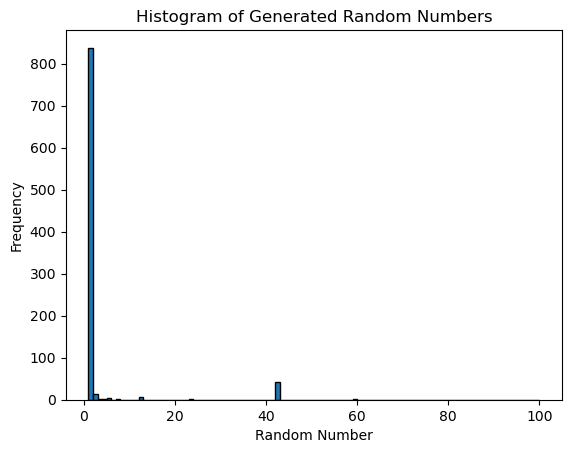

In [26]:
plt.hist(random_numbers, bins=range(1, 101), edgecolor='black')
plt.xlabel('Random Number')
plt.ylabel('Frequency')
plt.title('Histogram of Generated Random Numbers')
plt.show()

Most of the time it chose to output 1 or 42, which is not surprising since LLMs are not designed to generate truly random numbers. Their output reflects the patterns in the training data, and they may have learned that certain numbers are more common or more likely to be generated in response to certain prompts. To generate truly random numbers, it is better to use a dedicated random number generator tool or library, such as the random module in Python, which uses a pseudorandom number generator algorithm to produce random numbers that are uniformly distributed.

However, we can give LLMs the ability to use external tools to perform tasks that they are not designed for. For example, we can create a tool that generates random numbers and then allow the LLM to call this tool as part of its response generation process. This way, we can leverage the capabilities of the LLM for natural language understanding and generation, while using the external tool for generating truly random numbers.

:::{.callout-note}
Note: we show the following code for illustration only, as the small model we use does not support tool calling.
:::

```python
import random

# The actual Python function that generates a random number
def random_number_tool():
    return random.randint(1, 100)

# The tool schema that tells the LLM what tools are available and how to call them
tools = [
    {
        "type": "function",
        "function": {
            "name": "random_number_tool",
            "description": "Generate a uniformly distributed random number between 1 and 100",
            "parameters": {
                "type": "object",
                "properties": {},
                "required": []
            }
        }
    }
]
```

Note that the tool schema only describes the tool to the LLM. It does not contain the actual Python function. It is the LLM that decides whether to call the tool based on the schema, and it is up to our code to execute the actual function and return the result to the LLM. We can now define a function that sends a request to the LLM API, checks if the model wants to call a tool, executes the tool if needed, and sends the result back to the LLM to generate the final response.

```python
def generate_random_number_with_tool():

    messages = [
        {"role": "system", "content": "You are a professional random number generator. Use the random_number_tool to generate a uniformly distributed random number between 1 and 100. Only reply with the number."},
        {"role": "user", "content": "Generate a random number now."},
    ]

    # First API call: the model sees the available tools and decides whether to use one
    response = client.chat.completions.create(
        model = model,
        messages = messages,
        tools = tools
    )

    # Check if the model requested a tool call
    if response.choices[0].message.tool_calls:

        print("Model requested a tool call. Executing the tool...")

        tool_call = response.choices[0].message.tool_calls[0]

        # Execute the actual Python function
        result = random_number_tool()

        # Append the assistant's tool request and the tool result to the conversation
        messages.append(response.choices[0].message)
        messages.append({
            "role": "tool",
            "tool_call_id": tool_call.id,
            "content": str(result)
        })

        # Second API call: the model generates a final response using the tool result
        response = client.chat.completions.create(
            model = model,
            messages = messages,
            tools = tools
        )

    return response.choices[0].message.content

```

With this setup, the LLM can now generate truly random numbers by calling the external tool, while still leveraging its natural language understanding and generation capabilities for the rest of the conversation. Unfortunately, Gemma 3 (270m) is not able to use tools, but larger and more powerful models can learn to use tools effectively, which can significantly expand their capabilities and allow them to perform a wider range of tasks.